<div style="font-size: 60px;">
📖 Analysez les ventes d'une librairie
</div>

<div style="font-size: 42px;">
📓 Notebook préliminaire
</div>

# Import des librairies et paramètres généraux

In [1]:
import numpy as np
import pandas as pd
import plotly.express as px # renderer="png" requires kaleido (package) + plotly_get_chrome (terminal command)

In [2]:
data_path = "../data/"

# Analyse exploratoire des fichiers

## Analyse exploratoire du fichier `customers.csv`

In [3]:
df_customers = pd.read_csv(data_path + "raw/customers.csv", sep = ";", dtype = "str")
df_customers

,client_id,sex,birth
0,c_4410,f,1967
1,c_7839,f,1975
2,c_1699,f,1984
3,c_5961,f,1962
4,c_5320,m,1943
...,...,...,...
8616,c_7920,m,1956
8617,c_7403,f,1970
8618,c_5119,m,1974
8619,c_5643,f,1968


In [4]:
df_customers["birth"] = df_customers["birth"].astype(int)
df_customers.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8621 entries, 0 to 8620
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   client_id  8621 non-null   object
 1   sex        8621 non-null   object
 2   birth      8621 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 202.2+ KB


In [5]:
df_customers.nunique()

client_id    8621
sex             2
birth          76
dtype: int64

In [6]:
test_all = df_customers["client_id"].str.fullmatch(r"c_[1-9][0-9]*").all()
print(f"Tous les ID client respectent l'expression régulière ? {'OUI' if test_all else 'NON'}")

Tous les ID client respectent l'expression régulière ? OUI


In [7]:
df_sex_count = df_customers[["client_id","sex"]].groupby("sex").count().reset_index()
df_sex_count.rename(columns={"client_id":"count"}, inplace=True)
df_sex_count

,sex,count
0,f,4490
1,m,4131


In [8]:
df_customers["birth"].describe()

count    8621.000000
mean     1978.275606
std        16.917958
min      1929.000000
25%      1966.000000
50%      1979.000000
75%      1992.000000
max      2004.000000
Name: birth, dtype: float64

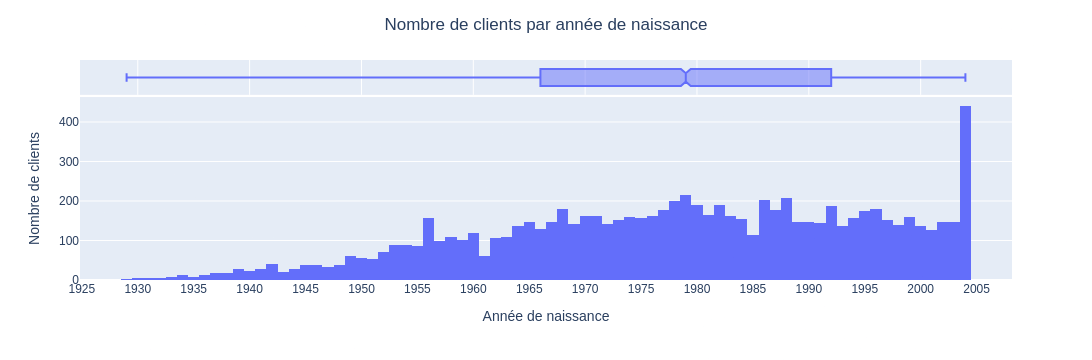

In [9]:
fig = px.histogram(df_customers, x="birth", labels={"birth":"Année de naissance"}, marginal="box")
fig.update_layout(xaxis_dtick=5, yaxis_title="Nombre de clients", title="Nombre de clients par année de naissance", title_x=0.5)
fig.show()

## Analyse exploratoire du fichier `products.csv`

In [10]:
df_products = pd.read_csv(data_path + "raw/products.csv", sep = ";", dtype = "str")
df_products

,id_prod,price,categ
0,0_1421,19.99,0
1,0_1368,5.13,0
2,0_731,17.99,0
3,1_587,4.99,1
4,0_1507,3.99,0
...,...,...,...
3281,2_23,115.99,2
3282,0_146,17.14,0
3283,0_802,11.22,0
3284,1_140,38.56,1


In [11]:
df_products["price"] = df_products["price"].astype(float)
df_products.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3286 entries, 0 to 3285
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id_prod  3286 non-null   object 
 1   price    3286 non-null   float64
 2   categ    3286 non-null   object 
dtypes: float64(1), object(2)
memory usage: 77.1+ KB


In [12]:
df_id_prod_split = df_products["id_prod"].str.split("_", expand=True).astype(int)
df_id_prod_split.columns = [ "prefix", "suffix" ]
df_id_prod_split.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3286 entries, 0 to 3285
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   prefix  3286 non-null   int64
 1   suffix  3286 non-null   int64
dtypes: int64(2)
memory usage: 51.5 KB


In [13]:
test_all = (df_id_prod_split["prefix"] == df_products["categ"].astype(int)).all()
print(f"Le préfixe de l'ID produit correspond toujours à la catégorie ? {'OUI' if test_all else 'NON'}")

Le préfixe de l'ID produit correspond toujours à la catégorie ? OUI


In [14]:
test_any_duplicated = df_id_prod_split["suffix"].duplicated(keep=False).any()
print(f"Chaque suffixe est unique ? {'NON' if test_any_duplicated else 'OUI'}")

Chaque suffixe est unique ? NON


In [15]:
print()
for prefix in np.sort(pd.unique(df_id_prod_split["prefix"])):
    tmp = df_id_prod_split["suffix"][ (df_id_prod_split["prefix"] == prefix) ]
    test_any_duplicated = tmp.duplicated(keep=False).any()
    vmin = tmp.min()
    vmax = tmp.max()
    missing = list(sorted(set(range(vmin, vmax)) - set(tmp)))
    print(f"Préfixe = {prefix}")
    print(f"Chaque suffixe est unique ? {'NON' if test_any_duplicated else 'OUI'}")
    print(f"ID prod : {tmp.size} valeurs, min = {vmin}, max = {vmax}, {len(missing)} valeur(s) manquante(s) {missing}")
    print()


Préfixe = 0
Chaque suffixe est unique ? OUI
ID prod : 2308 valeurs, min = 0, max = 2308, 1 valeur(s) manquante(s) [2245]

Préfixe = 1
Chaque suffixe est unique ? OUI
ID prod : 739 valeurs, min = 0, max = 738, 0 valeur(s) manquante(s) []

Préfixe = 2
Chaque suffixe est unique ? OUI
ID prod : 239 valeurs, min = 0, max = 238, 0 valeur(s) manquante(s) []



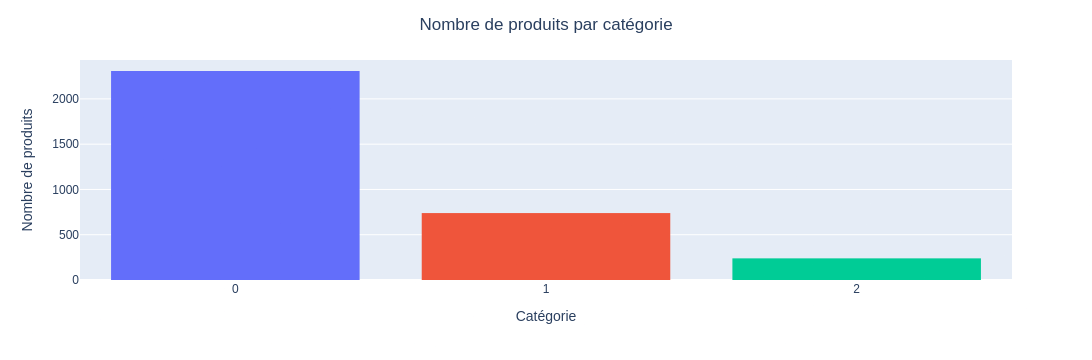

In [16]:
fig = px.histogram(df_products, x="categ", color="categ", labels={"categ":"Catégorie"})
fig.update_layout(yaxis_title="Nombre de produits", title="Nombre de produits par catégorie", title_x=0.5)
fig.update_layout(showlegend=False)
fig.show()

In [17]:
df_products["price"].describe()

count    3286.000000
mean       21.863597
std        29.849786
min         0.620000
25%         6.990000
50%        13.075000
75%        22.990000
max       300.000000
Name: price, dtype: float64

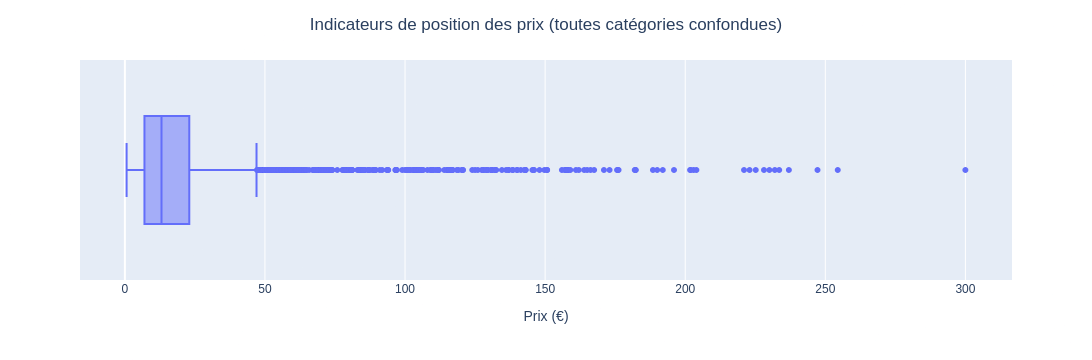

In [18]:
fig = px.box(df_products, x="price", hover_name="id_prod", labels={"price":"Prix (€)"})
fig.update_layout(title="Indicateurs de position des prix (toutes catégories confondues)", title_x=0.5)
fig.show()

In [19]:
print()
for categ in np.sort(pd.unique(df_products["categ"])):
    print(f"Description des prix pour la catégorie {categ}")
    print(df_products["price"][ (df_products["categ"] == categ) ].describe())
    print()


Description des prix pour la catégorie 0
count    2308.000000
mean       11.732795
std         7.565755
min         0.620000
25%         5.587500
50%        10.320000
75%        16.655000
max        40.990000
Name: price, dtype: float64

Description des prix pour la catégorie 1
count    739.000000
mean      25.531421
std       15.425162
min        2.000000
25%       13.390000
50%       22.990000
75%       33.990000
max       80.990000
Name: price, dtype: float64

Description des prix pour la catégorie 2
count    239.000000
mean     108.354686
std       49.561431
min       30.990000
25%       71.065000
50%      101.990000
75%      136.530000
max      300.000000
Name: price, dtype: float64



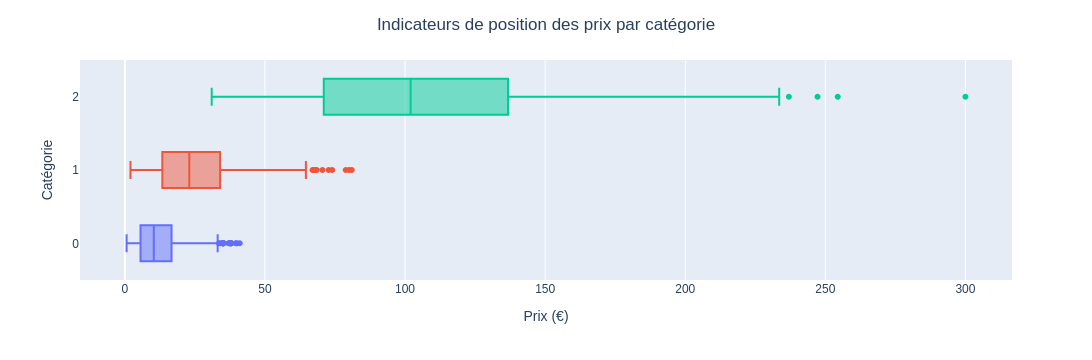

In [20]:
fig = px.box(df_products, x="price", y="categ", color="categ", hover_name="id_prod", labels={"price":"Prix (€)","categ":"Catégorie"})
fig.update_layout(showlegend=False, yaxis_categoryorder="category ascending")
fig.update_layout(title="Indicateurs de position des prix par catégorie", title_x=0.5)
fig.show()

## Analyse exploratoire du fichier `transactions.csv`

In [21]:
df_transactions = pd.read_csv(data_path + "raw/transactions.csv", sep = ";", dtype = str)
df_transactions

,id_prod,date,session_id,client_id
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033
...,...,...,...,...
1048570,NaN,NaN,NaN,NaN
1048571,NaN,NaN,NaN,NaN
1048572,NaN,NaN,NaN,NaN
1048573,NaN,NaN,NaN,NaN


In [22]:
df_transactions.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   id_prod     687534 non-null  object
 1   date        687534 non-null  object
 2   session_id  687534 non-null  object
 3   client_id   687534 non-null  object
dtypes: object(4)
memory usage: 32.0+ MB


In [23]:
test_empty_row = df_transactions.isna().all(axis=1)
test_empty_row

0          False
1          False
2          False
3          False
4          False
           ...  
1048570     True
1048571     True
1048572     True
1048573     True
1048574     True
Length: 1048575, dtype: bool

In [24]:
print(f"Nombre de lignes vide = {test_empty_row.sum()}")

Nombre de lignes vide = 361041


In [25]:
df_transactions.dropna(how="all", inplace=True)
df_transactions["date"] = pd.to_datetime(df_transactions["date"])
df_transactions.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 687534 entries, 0 to 687533
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   id_prod     687534 non-null  object        
 1   date        687534 non-null  datetime64[ns]
 2   session_id  687534 non-null  object        
 3   client_id   687534 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 26.2+ MB


In [26]:
test_all = df_transactions["session_id"].str.fullmatch(r"s_[1-9][0-9]*").all()
print(f"Tous les ID session respectent l'expression régulière ? {'OUI' if test_all else 'NON'}")

Tous les ID session respectent l'expression régulière ? OUI


In [27]:
test_all = df_transactions["client_id"].str.fullmatch(r"c_[1-9][0-9]*").all()
print(f"Tous les ID client respectent l'expression régulière ? {'OUI' if test_all else 'NON'}")

Tous les ID client respectent l'expression régulière ? OUI


In [28]:
test_all = df_transactions["id_prod"].str.fullmatch(r"[012]_(0|[1-9][0-9]*)").all()
print(f"Tous les ID produit respectent l'expression régulière ? {'OUI' if test_all else 'NON'}")

Tous les ID produit respectent l'expression régulière ? OUI


In [29]:
df_transactions.nunique()

id_prod         3265
date          687415
session_id    345505
client_id       8600
dtype: int64

### Analyse exploratoire des sessions

In [30]:
df_sessions = df_transactions.groupby("session_id").aggregate({
    "session_id": [ "count" ],
    "client_id" : [ "nunique" ],
    "id_prod": [ "nunique" ],
    "date": [ "nunique", "min", "max" ],
}).reset_index()
df_sessions[("date","delta")] = df_sessions[("date","max")] - df_sessions[("date","min")]
df_sessions

session_id       client_id id_prod    date                             \
                  count   nunique nunique nunique                        min   
0             s_1     1         1       1       1 2021-03-01 00:01:07.843138   
1            s_10     1         1       1       1 2021-03-01 00:10:33.163037   
2           s_100     2         1       2       2 2021-03-01 04:12:43.572994   
3          s_1000     4         1       4       4 2021-03-03 02:38:09.568389   
4         s_10000     3         1       3       3 2021-03-22 17:46:05.819130   
...           ...   ...       ...     ...     ...                        ...   
345500    s_99995     1         1       1       1 2021-10-04 18:35:32.201073   
345501    s_99996     4         1       4       4 2021-10-04 18:38:36.333661   
345502    s_99997     1         1       1       1 2021-10-04 18:45:38.003516   
345503    s_99998     3         1       3       3 2021-10-04 18:45:54.374885   
345504    s_99999     3         1       3       3 2021-10-09 10:38:08.231833   

                                                          
                              max                  delta  
0      2021-03-01 00:01:07.843138        0 days 00:00:00  
1      2021-03-01 00:10:33.163037        0 days 00:00:00  
2      2021-03-01 04:43:58.025677 0 days 00:31:14.452683  
3      2021-03-03 03:25:12.320225 0 days 00:47:02.751836  
4      2021-03-22 18:15:03.831240 0 days 00:28:58.012110  
...                           ...                    ...  
345500 2021-10-04 18:35:32.201073        0 days 00:00:00  
345501 2021-10-04 18:58:49.228317 0 days 00:20:12.894656  
345502 2021-10-04 18:45:38.003516        0 days 00:00:00  
345503 2021-10-04 19:00:20.030388 0 days 00:14:25.655503  
345504 2021-10-09 10:38:39.231833        0 days 00:00:31  

[345505 rows x 8 columns]

In [31]:
df_sessions.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 345505 entries, 0 to 345504
Data columns (total 8 columns):
 #   Column                Non-Null Count   Dtype          
---  ------                --------------   -----          
 0   (session_id, )        345505 non-null  object         
 1   (session_id, count)   345505 non-null  int64          
 2   (client_id, nunique)  345505 non-null  int64          
 3   (id_prod, nunique)    345505 non-null  int64          
 4   (date, nunique)       345505 non-null  int64          
 5   (date, min)           345505 non-null  datetime64[ns] 
 6   (date, max)           345505 non-null  datetime64[ns] 
 7   (date, delta)         345505 non-null  timedelta64[ns]
dtypes: datetime64[ns](2), int64(4), object(1), timedelta64[ns](1)
memory usage: 21.1+ MB


In [32]:
df_sessions.columns = [ "session_id", "count", "client_id nunique", "id_prod nunique", "date nunique", "date min", "date max", "date delta" ]
df_sessions.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 345505 entries, 0 to 345504
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype          
---  ------             --------------   -----          
 0   session_id         345505 non-null  object         
 1   count              345505 non-null  int64          
 2   client_id nunique  345505 non-null  int64          
 3   id_prod nunique    345505 non-null  int64          
 4   date nunique       345505 non-null  int64          
 5   date min           345505 non-null  datetime64[ns] 
 6   date max           345505 non-null  datetime64[ns] 
 7   date delta         345505 non-null  timedelta64[ns]
dtypes: datetime64[ns](2), int64(4), object(1), timedelta64[ns](1)
memory usage: 21.1+ MB


In [33]:
print(f"Au plus {df_sessions["count"].max()} ligne(s) par session")
print(f"Au plus {df_sessions["client_id nunique"].max()} client(s) par session")
print(f"Au plus {df_sessions["id_prod nunique"].max()} produit(s) par session")
print(f"Au plus {df_sessions["date nunique"].max()} date(s) par session")

Au plus 14 ligne(s) par session
Au plus 1 client(s) par session
Au plus 14 produit(s) par session
Au plus 14 date(s) par session


In [34]:
test_all = (df_sessions["client_id nunique"] == 1).any()
print(f"Toujours un seul client par session ? {'OUI' if test_all else 'NON'}")

Toujours un seul client par session ? OUI


In [35]:
test_all = (df_sessions["id_prod nunique"] == df_sessions["count"]).all()
print(f"Produits en doublon par session ? {'JAMAIS' if test_all else 'PARFOIS'}")

Produits en doublon par session ? PARFOIS


In [36]:
test_all = (df_sessions["date nunique"] == df_sessions["count"]).all()
print(f"Dates en doublon par session ? {'JAMAIS' if test_all else 'PARFOIS'}")

Dates en doublon par session ? PARFOIS


In [37]:
test_any = (df_sessions["id_prod nunique"] == df_sessions["date nunique"]).any()
print(f"Autant de produits que de dates dans une même session ? {'PARFOIS' if test_any else 'JAMAIS'}")

Autant de produits que de dates dans une même session ? PARFOIS


In [38]:
test_any = (df_sessions["id_prod nunique"] < df_sessions["date nunique"]).any()
print(f"Moins de produits que de dates dans une même session ? {'PARFOIS' if test_any else 'JAMAIS'}")

Moins de produits que de dates dans une même session ? PARFOIS


In [39]:
test_any = (df_sessions["id_prod nunique"] > df_sessions["date nunique"]).any()
print(f"Plus de produits que de dates dans une même session ? {'PARFOIS' if test_any else 'JAMAIS'}")

Plus de produits que de dates dans une même session ? PARFOIS


In [40]:
df_sessions["count"].describe()

count    345505.000000
mean          1.989939
std           1.276025
min           1.000000
25%           1.000000
50%           2.000000
75%           3.000000
max          14.000000
Name: count, dtype: float64

In [41]:
df_sessions["date delta"].describe()

count                       345505
mean     0 days 00:13:30.436175942
std      0 days 00:18:12.995892529
min                0 days 00:00:00
25%                0 days 00:00:00
50%         0 days 00:01:50.843234
75%         0 days 00:24:15.396307
max         0 days 02:01:10.566195
Name: date delta, dtype: object

In [42]:
df_sessions["date delta minutes"] = df_sessions["date delta"].dt.seconds / 60
df_sessions["date delta minutes"].describe()

count    345505.000000
mean         13.502928
std          18.213630
min           0.000000
25%           0.000000
50%           1.833333
75%          24.250000
max         121.166667
Name: date delta minutes, dtype: float64

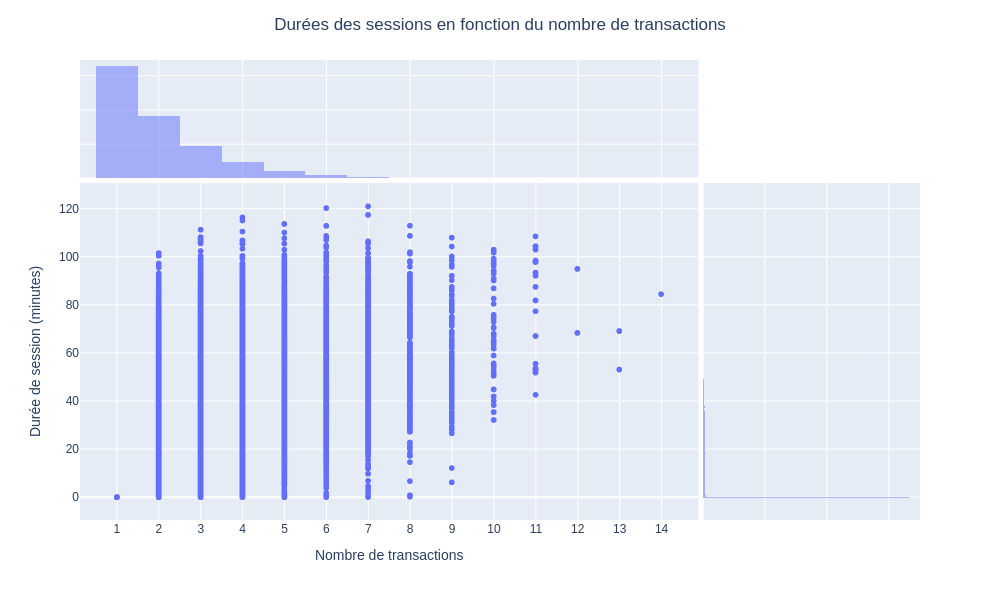

In [43]:
fig = px.scatter(
    df_sessions, y="date delta minutes", x="count", hover_name="session_id",
    category_orders={"count category":np.sort(pd.unique(df_sessions["count"]))},
    labels={"count":"Nombre de transactions","date delta minutes":"Durée de session (minutes)"},
    marginal_x="histogram", marginal_y="histogram", width=1000, height=600,
)
fig.update_layout(title="Durées des sessions en fonction du nombre de transactions", title_x=0.5)
fig.update_layout(xaxis_dtick=1)
fig.show(renderer="png") # export statique, diminue drastiquement la taille du notebook

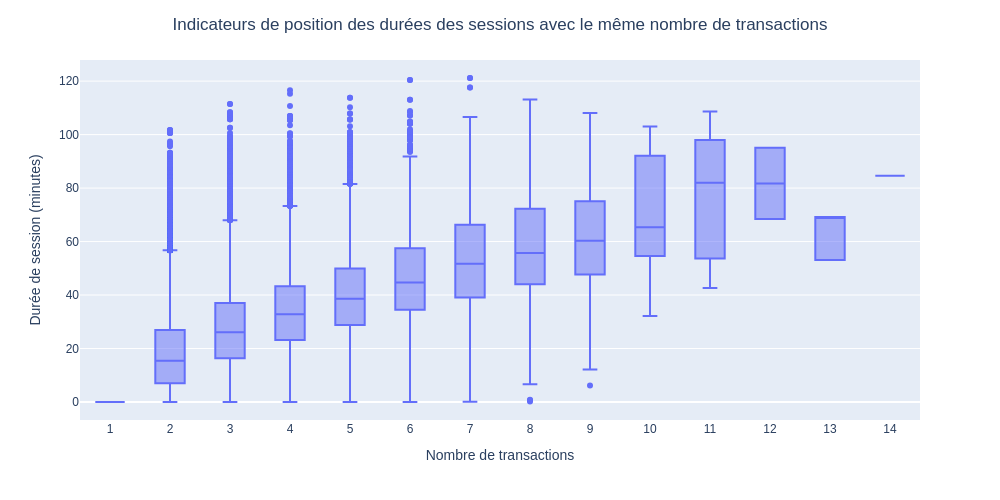

In [44]:
df_sessions["count category"] = df_sessions["count"].astype(str)
fig = px.box(
    df_sessions, y="date delta minutes", x="count category", hover_name="session_id", width=1000, height=500,
    category_orders={"count category":np.sort(pd.unique(df_sessions["count"]))},
    labels={"count category":"Nombre de transactions","date delta minutes":"Durée de session (minutes)"},
)
del df_sessions["count category"]
fig.update_layout(title="Indicateurs de position des durées des sessions avec le même nombre de transactions", title_x=0.5)
fig.show(renderer="png") # export statique, diminue drastiquement la taille du notebook

# Jointures

## Jointure entre transactions et clients

In [45]:
df_merge = pd.merge(df_transactions, df_customers, on="client_id", how="outer", indicator="indicator")
df_merge.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 687555 entries, 0 to 687554
Data columns (total 7 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   id_prod     687534 non-null  object        
 1   date        687534 non-null  datetime64[ns]
 2   session_id  687534 non-null  object        
 3   client_id   687555 non-null  object        
 4   sex         687555 non-null  object        
 5   birth       687555 non-null  int64         
 6   indicator   687555 non-null  category      
dtypes: category(1), datetime64[ns](1), int64(1), object(4)
memory usage: 32.1+ MB


In [46]:
df_merge.groupby("indicator", observed=False)["indicator"].count()

indicator
left_only          0
right_only        21
both          687534
Name: indicator, dtype: int64

In [47]:
client_id_without_transaction = df_merge["client_id"][ (df_merge["indicator"] == "right_only") ]
df_customers_without_transaction = df_customers[ df_customers["client_id"].isin(client_id_without_transaction) ]
df_customers_without_transaction

,client_id,sex,birth
801,c_8253,f,2001
2483,c_3789,f,1997
2734,c_4406,f,1998
2768,c_2706,f,1967
2850,c_3443,m,1959
3178,c_4447,m,1956
3189,c_3017,f,1992
3333,c_4086,f,1992
3720,c_6930,m,2004
3820,c_4358,m,1999


In [48]:
df_customers_without_transaction.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 21 entries, 801 to 8534
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   client_id  21 non-null     object
 1   sex        21 non-null     object
 2   birth      21 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 672.0+ bytes


In [49]:
df_merge.dropna(how="any", inplace=True)

In [50]:
df_merge.groupby("indicator", observed=False)["indicator"].count()

indicator
left_only          0
right_only         0
both          687534
Name: indicator, dtype: int64

In [51]:
del df_merge["indicator"]
df_merge.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 687534 entries, 0 to 687554
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   id_prod     687534 non-null  object        
 1   date        687534 non-null  datetime64[ns]
 2   session_id  687534 non-null  object        
 3   client_id   687534 non-null  object        
 4   sex         687534 non-null  object        
 5   birth       687534 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(4)
memory usage: 36.7+ MB


## Jointure avec les produits

In [52]:
df_merge = pd.merge(df_products, df_merge, on="id_prod", how="outer", indicator="indicator")
df_merge.info(verbose=True) # Warning: outer merge causes a dtype conversion for "birth" from int64 to float64 (NaN)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 687555 entries, 0 to 687554
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   id_prod     687555 non-null  object        
 1   price       687555 non-null  float64       
 2   categ       687555 non-null  object        
 3   date        687534 non-null  datetime64[ns]
 4   session_id  687534 non-null  object        
 5   client_id   687534 non-null  object        
 6   sex         687534 non-null  object        
 7   birth       687534 non-null  float64       
 8   indicator   687555 non-null  category      
dtypes: category(1), datetime64[ns](1), float64(2), object(5)
memory usage: 42.6+ MB


In [53]:
df_merge.groupby("indicator", observed=False)["indicator"].count()

indicator
left_only         21
right_only         0
both          687534
Name: indicator, dtype: int64

In [54]:
id_prod_without_transaction = df_merge["id_prod"][ (df_merge["indicator"] == "left_only") ]
df_products_without_transaction = df_products[ df_products["id_prod"].isin(id_prod_without_transaction) ]
df_products_without_transaction

,id_prod,price,categ
184,0_1016,35.06,0
279,0_1780,1.67,0
736,0_1062,20.08,0
793,0_1119,2.99,0
810,0_1014,1.15,0
845,1_0,31.82,1
1030,0_1318,20.92,0
1138,0_1800,22.05,0
1346,0_1645,2.99,0
1504,0_322,2.99,0


In [55]:
df_products_without_transaction.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 21 entries, 184 to 3095
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id_prod  21 non-null     object 
 1   price    21 non-null     float64
 2   categ    21 non-null     object 
dtypes: float64(1), object(2)
memory usage: 672.0+ bytes


In [56]:
df_products_without_transaction.groupby("categ")["id_prod"].count()

categ
0    16
1     2
2     3
Name: id_prod, dtype: int64

In [57]:
df_merge.dropna(how="any", inplace=True)

In [58]:
df_merge.groupby("indicator", observed=False)["indicator"].count()

indicator
left_only          0
right_only         0
both          687534
Name: indicator, dtype: int64

In [59]:
del df_merge["indicator"]
df_merge["birth"] = df_merge["birth"].astype(int)
df_merge.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 687534 entries, 0 to 687554
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   id_prod     687534 non-null  object        
 1   price       687534 non-null  float64       
 2   categ       687534 non-null  object        
 3   date        687534 non-null  datetime64[ns]
 4   session_id  687534 non-null  object        
 5   client_id   687534 non-null  object        
 6   sex         687534 non-null  object        
 7   birth       687534 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 47.2+ MB


## Calcul de l'âge du client au moment de la transaction

In [60]:
df_merge["age"] = df_merge["date"].dt.year - df_merge["birth"] + 1
df_merge["age"].describe()

count    687534.000000
mean         44.844898
std          13.623882
min          18.000000
25%          36.000000
50%          43.000000
75%          52.000000
max          95.000000
Name: age, dtype: float64

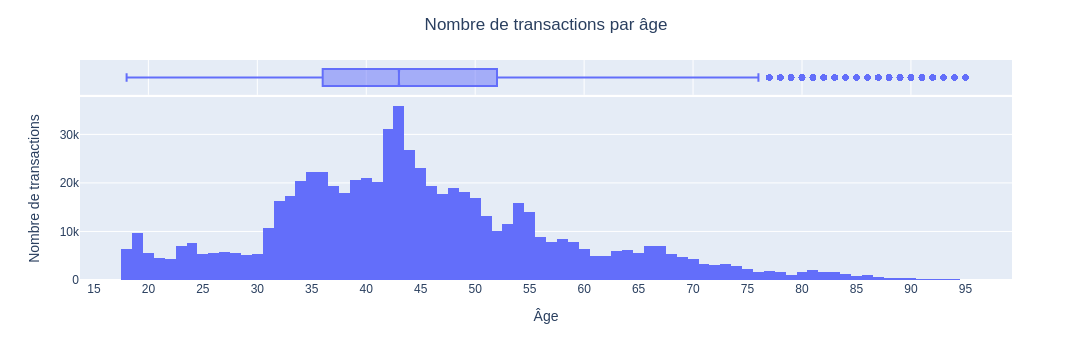

In [61]:
fig = px.histogram(df_merge, x="age", labels={"age":"Âge"}, marginal="box")
fig.update_layout(xaxis_dtick=5, yaxis_title="Nombre de transactions")
fig.update_layout(title="Nombre de transactions par âge", title_x=0.5)
fig.show()

In [62]:
df_tmp = df_merge.groupby("client_id").agg({"age":"mean"}).reset_index()
df_tmp.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8600 entries, 0 to 8599
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   client_id  8600 non-null   object 
 1   age        8600 non-null   float64
dtypes: float64(1), object(1)
memory usage: 134.5+ KB


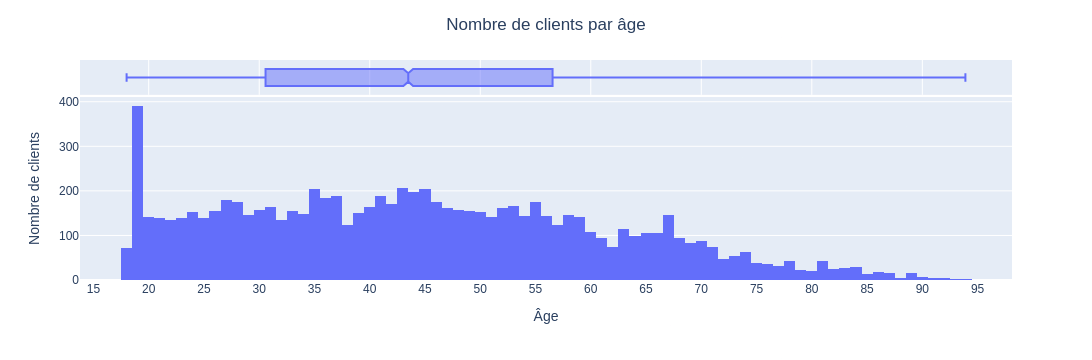

In [63]:
fig = px.histogram(df_tmp, x="age", labels={"age":"Âge"}, marginal="box")
fig.update_layout(xaxis_dtick=5, yaxis_title="Nombre de clients")
fig.update_layout(title="Nombre de clients par âge", title_x=0.5)
fig.show()

### Changement d'âge du client au cours d'une session

In [64]:
df_sessions = df_merge.groupby(["client_id","birth","session_id"]).agg({
    "id_prod": [ "count", "nunique" ],
    "age": [ "min", "max", "nunique" ],
    "date": [ "min", "max" ],
})
df_sessions = df_sessions[ (df_sessions[("age","nunique")] != 1) ]
df_sessions

id_prod         age              \
                             count nunique min max nunique   
client_id birth session_id                                   
c_2601    1997  s_143108         5       5  25  26       2   
c_3377    1981  s_143097         3       3  41  42       2   
c_571     1984  s_143109         3       3  38  39       2   

                                                 date  \
                                                  min   
client_id birth session_id                              
c_2601    1997  s_143108   2021-12-31 23:32:34.177312   
c_3377    1981  s_143097   2021-12-31 23:11:24.214329   
c_571     1984  s_143109   2021-12-31 23:37:31.292956   

                                                       
                                                  max  
client_id birth session_id                             
c_2601    1997  s_143108   2022-01-01 00:41:49.059264  
c_3377    1981  s_143097   2022-01-01 00:06:23.031437  
c_571     1984  s_143109   2022-01-01 00:10:52.986913

# Segmentation des clients

## Agrégation des informations par client

In [65]:
df_groupby_customer = df_merge.groupby([*df_customers.columns]).aggregate({ "price": [ "count", "sum" ] }).reset_index()
df_groupby_customer.columns = [ *df_customers.columns, "nb_transactions", "total_amount_spent" ]
df_groupby_customer

,client_id,sex,birth,nb_transactions,total_amount_spent
0,c_1,m,1955,43,629.02
1,c_10,m,1956,58,1353.60
2,c_100,m,1992,8,254.85
3,c_1000,f,1966,126,2291.88
4,c_1001,m,1982,103,1823.85
...,...,...,...,...,...
8595,c_995,m,1955,14,189.41
8596,c_996,f,1970,96,1637.34
8597,c_997,f,1994,59,1490.01
8598,c_998,m,2001,55,2822.22


## Analyse du chiffre d'affaires par client

In [66]:
df_groupby_customer["total_amount_spent"].describe()

count      8600.000000
mean       1398.565477
std        5202.771679
min           6.310000
25%         562.730000
50%        1045.695000
75%        1797.720000
max      326039.890000
Name: total_amount_spent, dtype: float64

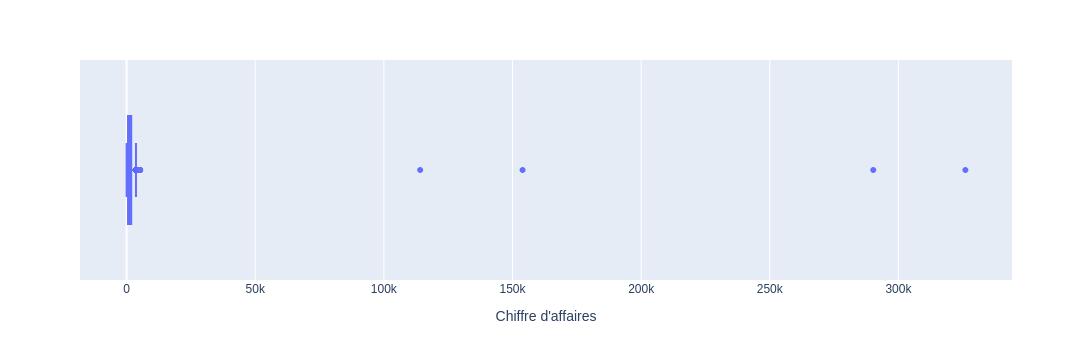

In [67]:
px.box(
    df_groupby_customer, x="total_amount_spent", hover_name="client_id", hover_data={"nb_transactions":":d","total_amount_spent":":.2f"},
    labels={"client_id":"ID client","nb_transactions":"Nombre de transactions","total_amount_spent":"Chiffre d'affaires"},
)

In [68]:
df_groupby_customer[ (df_groupby_customer["total_amount_spent"] > 100_000) ]

,client_id,sex,birth,nb_transactions,total_amount_spent
677,c_1609,m,1980,25586,326039.89
2724,c_3454,m,1969,6793,114110.57
4388,c_4958,m,1999,5222,290227.03
6337,c_6714,f,1968,9199,153918.60


## Analyse du nombre de transactions par client

In [69]:
df_groupby_customer["nb_transactions"].describe()

count     8600.000000
mean        79.945814
std        313.532311
min          1.000000
25%         28.000000
50%         52.000000
75%         97.000000
max      25586.000000
Name: nb_transactions, dtype: float64

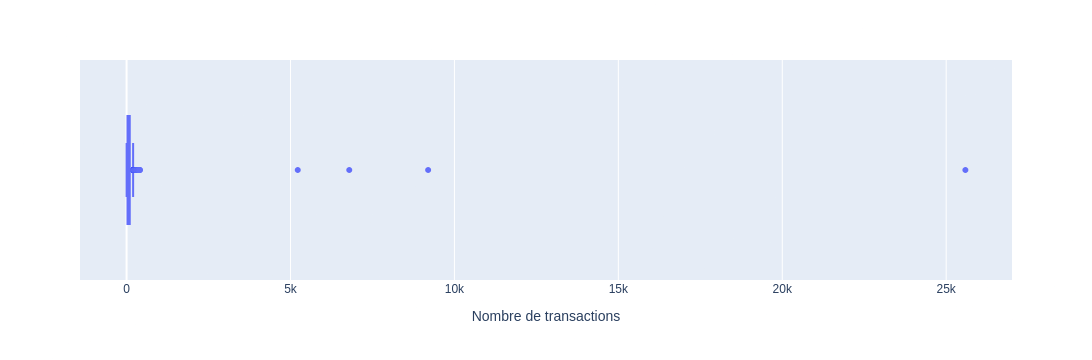

In [70]:
px.box(
    df_groupby_customer, x="nb_transactions", hover_name="client_id", hover_data={"nb_transactions":":d","total_amount_spent":":.2f"},
    labels={"client_id":"ID client","nb_transactions":"Nombre de transactions","total_amount_spent":"Chiffre d'affaires"},
)

In [71]:
df_groupby_customer[ (df_groupby_customer["nb_transactions"] > 5_000) ]

,client_id,sex,birth,nb_transactions,total_amount_spent
677,c_1609,m,1980,25586,326039.89
2724,c_3454,m,1969,6793,114110.57
4388,c_4958,m,1999,5222,290227.03
6337,c_6714,f,1968,9199,153918.60


## Ajout de l'indicateur `client_type`

In [72]:
client_types = ["B2C","B2B"]
category_orders = {"client_type":client_types}

In [73]:
df_groupby_customer["client_type"] = (df_groupby_customer["total_amount_spent"] > 100_000).map(client_types.__getitem__)
df_groupby_customer

,client_id,sex,birth,nb_transactions,total_amount_spent,client_type
0,c_1,m,1955,43,629.02,B2C
1,c_10,m,1956,58,1353.60,B2C
2,c_100,m,1992,8,254.85,B2C
3,c_1000,f,1966,126,2291.88,B2C
4,c_1001,m,1982,103,1823.85,B2C
...,...,...,...,...,...,...
8595,c_995,m,1955,14,189.41,B2C
8596,c_996,f,1970,96,1637.34,B2C
8597,c_997,f,1994,59,1490.01,B2C
8598,c_998,m,2001,55,2822.22,B2C


In [74]:
df_groupby_customer_b2c = df_groupby_customer[ (df_groupby_customer["client_type"] == "B2C") ]
df_groupby_customer_b2b = df_groupby_customer[ (df_groupby_customer["client_type"] == "B2B") ]
df_groupby_customer_b2b

,client_id,sex,birth,nb_transactions,total_amount_spent,client_type
677,c_1609,m,1980,25586,326039.89,B2B
2724,c_3454,m,1969,6793,114110.57,B2B
4388,c_4958,m,1999,5222,290227.03,B2B
6337,c_6714,f,1968,9199,153918.60,B2B


In [75]:
df_merge["client_type"] = df_merge["client_id"].isin(df_groupby_customer_b2b["client_id"]).map(client_types.__getitem__)
df_merge

,id_prod,price,categ,date,session_id,client_id,sex,birth,age,client_type
0,0_0,3.75,0,2021-03-02 21:57:33.862118,s_908,c_1004,m,1973,49,B2C
1,0_0,3.75,0,2022-02-18 16:40:10.068303,s_167174,c_1011,f,1999,24,B2C
2,0_0,3.75,0,2022-03-18 16:40:10.068303,s_180968,c_1011,f,1999,24,B2C
3,0_0,3.75,0,2022-04-18 16:40:10.068303,s_195932,c_1011,f,1999,24,B2C
4,0_0,3.75,0,2023-02-18 16:40:10.068303,s_343439,c_1011,f,1999,25,B2C
...,...,...,...,...,...,...,...,...,...,...
687550,2_99,84.99,2,2022-07-21 01:53:46.967570,s_241374,c_5828,f,1998,25,B2C
687551,2_99,84.99,2,2023-01-21 01:53:46.967570,s_329932,c_5828,f,1998,26,B2C
687552,2_99,84.99,2,2021-07-11 20:56:49.820935,s_61009,c_7135,m,1996,26,B2C
687553,2_99,84.99,2,2022-11-11 20:56:49.820935,s_296127,c_7135,m,1996,27,B2C


In [76]:
df_merge_b2c = df_merge[ (df_merge["client_type"] == "B2C") ]
df_merge_b2b = df_merge[ (df_merge["client_type"] == "B2B") ]

## Répartition entre clients B2C et B2B

In [77]:
df_groupby_b2X = df_groupby_customer.groupby("client_type", observed=False)[["nb_transactions","total_amount_spent"]].sum().reset_index()
df_groupby_b2X

,client_type,nb_transactions,total_amount_spent
0,B2B,46800,884296.09
1,B2C,640734,11143367.01


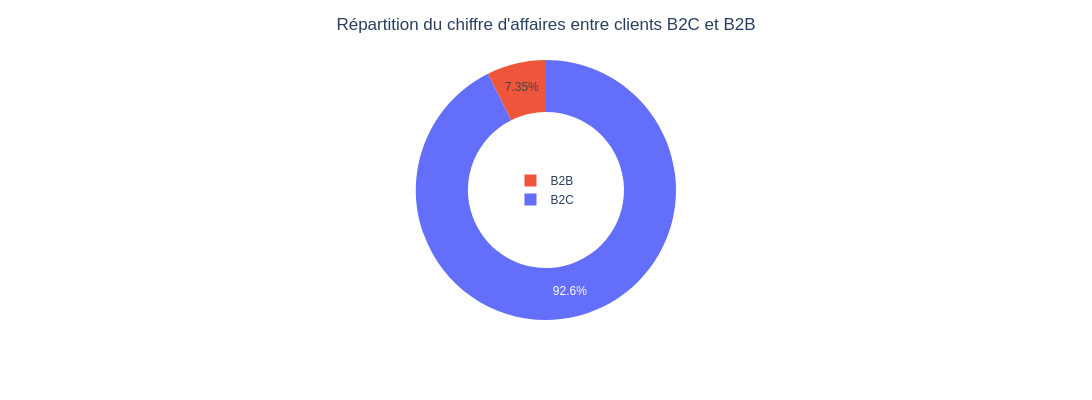

In [78]:
fig = px.pie(
    df_groupby_b2X, names="client_type", values="total_amount_spent",
    # hover_data={"client_type":False,"nb_transactions":":d","total_amount_spent":":.2f"}, # @bug px.pie() with multiple hover_data
    labels={"client_type":"Type de client","nb_transactions":"Nombre de transactions","total_amount_spent":"Chiffre d'affaires"},
    category_orders=category_orders, hole=0.6, width=600, height=400,
)
fig.update_layout(title="Répartition du chiffre d'affaires entre clients B2C et B2B", title_x=0.5)
fig.update_layout(legend=dict(x=0.5, y=0.5, xanchor="center", yanchor="middle", traceorder="reversed"))
fig.show()

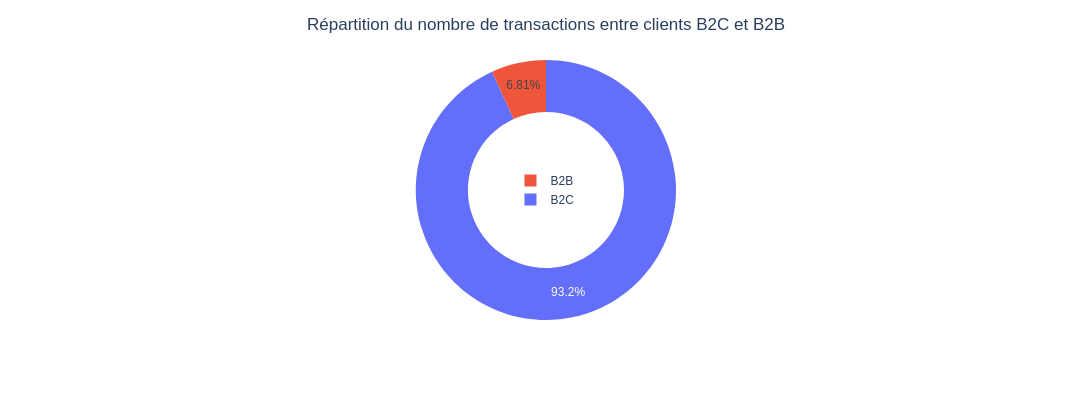

In [79]:
fig = px.pie(
    df_groupby_b2X, names="client_type", values="nb_transactions",
    # hover_data={"client_type":False,"nb_transactions":":d","total_amount_spent":":.2f"}, # @bug px.pie() with multiple hover_data
    labels={"client_type":"Type de client","nb_transactions":"Nombre de transactions","total_amount_spent":"Chiffre d'affaires"},
    category_orders=category_orders, hole=0.6, width=600, height=400,
)
fig.update_layout(title="Répartition du nombre de transactions entre clients B2C et B2B", title_x=0.5)
fig.update_layout(legend=dict(x=0.5, y=0.5, xanchor="center", yanchor="middle", traceorder="reversed"))
fig.show()

# Export des données pour les analyses

In [80]:
df_merge.to_csv(data_path + "processed/merge.csv", index = False)